# Aperture-limited probe

Quick sanity check: propagate a circular aperture wave through a single lens and compare the Gaussian-ray probe image against the Fourier-transform of the aperture field.


## Setup


In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.2"

import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp

from temgym_core.components import Detector
from temgym_core.constants import energy2wavelength
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.components import Lens
from temgym_core.run import run_to_end
from temgym_core.source import circular_input_wave

jax.config.update("jax_enable_x64", True)

%matplotlib widget



## Geometry and sampling


In [2]:
voltage = 100_000  # volts
wavelength = energy2wavelength(voltage)  # meters

input_window_width = 100e-6
aperture_radius = 10e-6
aperture_window_width = input_window_width
lens_f = 1e-3

Nx = Ny = 256
input_pixel_x = input_window_width / Nx
input_pixel_y = input_window_width / Ny
output_pixel = float(wavelength) * abs(lens_f) / aperture_window_width

input_aperture_grid = Detector(
    z=0.0,
    pixel_size=(input_pixel_x, input_pixel_y),
    shape=(Nx, Ny),
)
input_extent = input_aperture_grid.extent


## Circular aperture field


In [3]:
input_waist = 2e-7
rays_in = circular_input_wave(
    voltage=voltage,
    aperture_radius=aperture_radius,
    waist=input_waist,
    offset_xy=(0.0, 0.0),
    sampling="uniform",
).to_vector()

run_to_end_vmapped = jax.vmap(run_to_end, in_axes=(0, None))

rays_after_aperture = run_to_end(rays_in, ())
input_aperture_field = evaluate_gaussians_gpu_kernel_wrapper(
    rays_after_aperture, input_aperture_grid
)


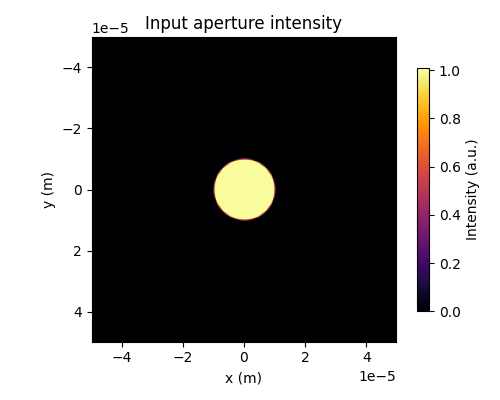

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(
    jnp.abs(input_aperture_field),
    extent=input_extent,
    origin="lower",
    cmap="inferno",
)
ax.set_title("Input aperture intensity")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Intensity (a.u.)")
fig.tight_layout()


## Propagate through the lens to the probe plane


In [5]:
lens = Lens(z=lens_f, focal_length=lens_f)
output_probe_grid = Detector(
    z=2 * lens_f,
    pixel_size=(output_pixel, output_pixel),
    shape=(Nx, Ny),
)
output_extent = output_probe_grid.extent
output_x, output_y = output_probe_grid.coords_1d

rays_after_lens = run_to_end_vmapped(rays_in, (lens, output_probe_grid))

Q_inv_imag = rays_after_lens.Q_inv[0, 0, 0].imag
w_out = jnp.sqrt(wavelength / (jnp.pi * Q_inv_imag))
print(f"Approx. beam waist at focus: {float(w_out * 1e6):.3f} um")


Approx. beam waist at focus: 0.006 um


In [6]:
probe_image = evaluate_gaussians_gpu_kernel_wrapper(rays_after_lens, output_probe_grid)


## Fourier-transform reference from the aperture field


In [7]:
du, dv = input_pixel_x, input_pixel_y
diffraction_of_aperture = jnp.fft.ifftshift(jnp.fft.fft2(input_aperture_field))
# Energy-conserving scaling for the FFT propagation to the focal plane
diffraction_of_aperture *= (du * dv) / (1j * wavelength * lens_f)


## Probe intensity vs aperture FFT


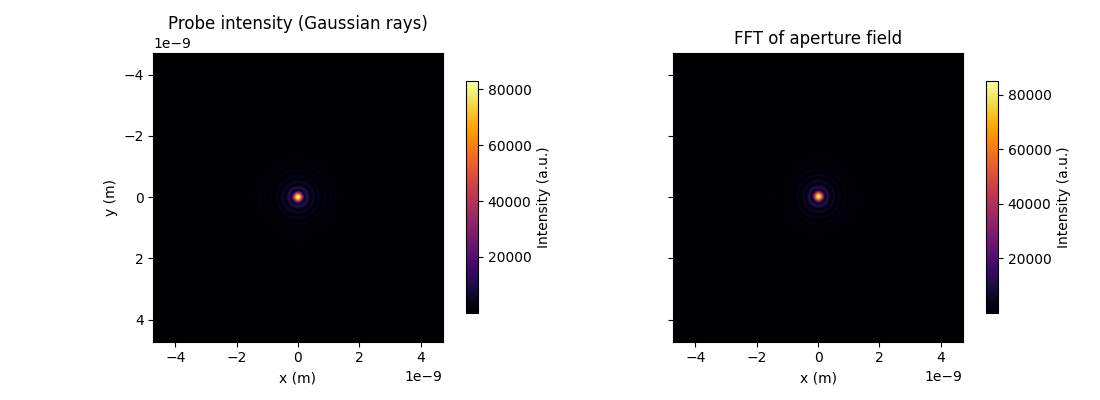

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
im0 = ax[0].imshow(
    jnp.abs(probe_image),
    extent=output_extent,
    origin="lower",
    cmap="inferno",
)
ax[0].set_title("Probe intensity (Gaussian rays)")

im1 = ax[1].imshow(
    jnp.abs(diffraction_of_aperture),
    extent=output_extent,
    origin="lower",
    cmap="inferno",
)
ax[1].set_title("FFT of aperture field")

for axis in ax:
    axis.set_xlabel("x (m)")
ax[0].set_ylabel("y (m)")

fig.colorbar(im0, ax=ax[0], shrink=0.8, label="Intensity (a.u.)")
fig.colorbar(im1, ax=ax[1], shrink=0.8, label="Intensity (a.u.)")
fig.tight_layout()


## Central cross-section


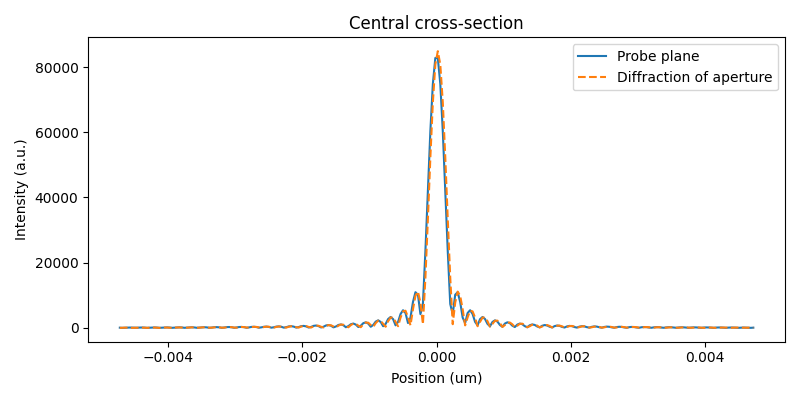

: 

In [ ]:
center = Nx // 2
output_x_um = np.asarray(output_x) * 1e6

probe_line = np.abs(np.asarray(probe_image)[center, :])
fft_line = np.abs(np.asarray(diffraction_of_aperture)[center, :])

plt.figure(figsize=(8, 4))
plt.plot(output_x_um, probe_line, label="Probe plane")
plt.plot(output_x_um, fft_line, "--", label="Diffraction of aperture")
plt.xlabel("Position (um)")
plt.ylabel("Intensity (a.u.)")
plt.title("Central cross-section")
plt.legend()
plt.tight_layout()
